# Deep Post-Hoc Analysis — Key Signature Errors
### Katherine (ZhaoYu) Tu — Master Thesis
**University of Amsterdam, 2026**

Append these cells to `post_hoc_analysis.ipynb` after Cell 6.
Run Cell 1 and 2 of the main notebook first so `df1`, `df3`,
and all helpers are available.

---
**Analyses in this notebook:**
1. Relative major/minor confusion
2. Enharmonic equivalence errors + relaxed accuracy
3. Accidental direction errors (sharp vs flat confusion)
4. Circle of fifths error distance
5. Per-model error overlap (shared hard movements)

---
## Setup — Music theory reference tables
Run this cell first. It defines all the mappings needed for the 5 analyses.

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings("ignore")

In [2]:
# ── PATHS ─────────────────────────────────────────────────────────────────────
BASE_DIR    = Path("/Users/katherine.tu/Master Thesis/beethoven_piano_sonatas")
RESULTS_DIR = BASE_DIR / "results"

SRQ1_FILE = RESULTS_DIR / "srq1_results_fixed.jsonl"
SRQ3_FILE = RESULTS_DIR / "srq3_results.jsonl"

MODELS = ["claude-sonnet-4-6", "gemini-2.5-flash", "gpt-5.4"]
TASKS  = ["key_signature", "time_signature"]

# ── LOADER ────────────────────────────────────────────────────────────────────
def load_jsonl(filepath):
    records = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)

df1 = load_jsonl(SRQ1_FILE)
df3 = load_jsonl(SRQ3_FILE)
print(f"SRQ1: {len(df1)} entries | SRQ3: {len(df3)} entries")

# ── KEY NORMALISATION HELPERS ─────────────────────────────────────────────────
def dcml_key_to_standard(dcml_key):
    if not dcml_key:
        return None, None
    quality = "major" if dcml_key[0].isupper() else "minor"
    return dcml_key.lower(), quality

def normalise_key_for_comparison(raw_key):
    if not raw_key:
        return None, None
    raw = raw_key.strip()
    if len(raw) <= 3 and " " not in raw:
        return dcml_key_to_standard(raw)
    raw_lower = raw.lower()
    if "major" in raw_lower or "maj" in raw_lower:
        quality = "major"
    elif "minor" in raw_lower or "min" in raw_lower:
        quality = "minor"
    else:
        quality = "major"
    note = raw_lower
    for word in ["major", "minor", "maj", "min"]:
        note = note.replace(word, "")
    note = note.strip().rstrip("-").strip()
    note = note.replace("flat", "b").replace("sharp", "#")
    note = note.replace("\u266d", "b").replace("\u266f", "#")
    note = note.replace("-", "").replace(" ", "")
    return note, quality

def keys_match(ground_truth_val, parsed_answer):
    if not ground_truth_val or not parsed_answer:
        return False
    gt_note, gt_quality     = dcml_key_to_standard(str(ground_truth_val))
    pred_note, pred_quality = normalise_key_for_comparison(parsed_answer)
    return gt_note == pred_note and gt_quality == pred_quality

def normalise_for_sklearn(val, question_type):
    if not val or str(val).strip() == "":
        return "unknown"
    val = str(val).strip()
    if question_type == "key_signature":
        if len(val) <= 3 and " " not in val:
            note, quality = dcml_key_to_standard(val)
            if note and quality:
                return f"{note} {quality}"
        note, quality = normalise_key_for_comparison(val)
        if note and quality:
            return f"{note} {quality}"
        return val.lower()
    return val.lower().strip()

print("All helpers loaded. Ready to run analyses.")

SRQ1: 459 entries | SRQ3: 918 entries
All helpers loaded. Ready to run analyses.


In [3]:
# ── CIRCLE OF FIFTHS ──────────────────────────────────────────────────────────
# Position 0 = C/a, position 1 = G/e, ..., position 11 = F/d
# Each key maps to its position (0-11) on the circle.
# Distance between two keys = min(|pos_a - pos_b|, 12 - |pos_a - pos_b|)

MAJOR_COF = {
    "c major":  0,  "g major":  1,  "d major":  2,  "a major":  3,
    "e major":  4,  "b major":  5,  "f# major": 6,  "gb major": 6,
    "db major": 7,  "c# major": 7,  "ab major": 8,  "g# major": 8,
    "eb major": 9,  "d# major": 9,  "bb major": 10, "a# major": 10,
    "f major":  11
}

MINOR_COF = {
    "a minor":  0,  "e minor":  1,  "b minor":  2,  "f# minor": 3,
    "c# minor": 4,  "g# minor": 5,  "d# minor": 6,  "eb minor": 6,
    "bb minor": 7,  "a# minor": 7,  "f minor":  8,  "e# minor": 8,
    "c minor":  9,  "g minor":  10, "d minor":  11
}

def cof_position(key_str):
    """Return circle-of-fifths position (0-11) for a normalised key string."""
    k = key_str.lower().strip()
    if "major" in k:
        return MAJOR_COF.get(k)
    elif "minor" in k:
        return MINOR_COF.get(k)
    return None

def cof_distance(key_a, key_b):
    """Circular distance on the circle of fifths (0-6)."""
    pos_a = cof_position(key_a)
    pos_b = cof_position(key_b)
    if pos_a is None or pos_b is None:
        return None
    diff = abs(pos_a - pos_b)
    return min(diff, 12 - diff)


# ── RELATIVE MAJOR/MINOR PAIRS ────────────────────────────────────────────────
# Each major key has a relative minor (same key signature, different tonic)
# e.g. C major and A minor both have 0 sharps/flats

RELATIVE_PAIRS = {
    "c major":  "a minor",  "a minor":  "c major",
    "g major":  "e minor",  "e minor":  "g major",
    "d major":  "b minor",  "b minor":  "d major",
    "a major":  "f# minor", "f# minor": "a major",
    "e major":  "c# minor", "c# minor": "e major",
    "b major":  "g# minor", "g# minor": "b major",
    "f# major": "d# minor", "d# minor": "f# major",
    "gb major": "eb minor", "eb minor": "gb major",
    "db major": "bb minor", "bb minor": "db major",
    "ab major": "f minor",  "f minor":  "ab major",
    "eb major": "c minor",  "c minor":  "eb major",
    "bb major": "g minor",  "g minor":  "bb major",
    "f major":  "d minor",  "d minor":  "f major",
}

def is_relative_confusion(true_key, pred_key):
    """Return True if pred_key is the relative major/minor of true_key."""
    return RELATIVE_PAIRS.get(true_key.lower().strip()) == pred_key.lower().strip()


# ── ENHARMONIC EQUIVALENTS ────────────────────────────────────────────────────
# Keys that sound identical but are written differently

ENHARMONIC_PAIRS = [
    {"f# major", "gb major"},
    {"c# major", "db major"},
    {"g# major", "ab major"},
    {"d# major", "eb major"},
    {"a# major", "bb major"},
    {"d# minor", "eb minor"},
    {"a# minor", "bb minor"},
    {"e# minor", "f minor"},
    {"b# minor", "c minor"},
]

def is_enharmonic(key_a, key_b):
    """Return True if key_a and key_b are enharmonic equivalents."""
    pair = {key_a.lower().strip(), key_b.lower().strip()}
    return any(pair == ep for ep in ENHARMONIC_PAIRS)


# ── ACCIDENTAL DIRECTION ──────────────────────────────────────────────────────
# Classify each key as sharp, flat, or natural (no accidentals)

SHARP_KEYS = {
    "g major", "d major", "a major", "e major", "b major",
    "f# major", "c# major",
    "e minor", "b minor", "f# minor", "c# minor",
    "g# minor", "d# minor", "a# minor"
}
FLAT_KEYS = {
    "f major", "bb major", "eb major", "ab major",
    "db major", "gb major",
    "d minor", "g minor", "c minor", "f minor",
    "bb minor", "eb minor", "ab minor"
}
NATURAL_KEYS = {"c major", "a minor"}

def accidental_direction(key_str):
    """Return 'sharp', 'flat', or 'natural' for a normalised key string."""
    k = key_str.lower().strip()
    if k in SHARP_KEYS:   return "sharp"
    if k in FLAT_KEYS:    return "flat"
    if k in NATURAL_KEYS: return "natural"
    return "unknown"


# ── BUILD ERROR TABLE (key signature only, both SRQ1 and SRQ3) ───────────────
# We'll reuse this table across all 5 analyses.

def build_key_error_table(df, srq_label):
    """
    Extract all incorrect key signature predictions from a results DataFrame.
    Returns a DataFrame with one row per error, enriched with:
    - normalised ground truth and prediction
    - relative confusion flag
    - enharmonic flag
    - accidental direction for true and predicted key
    - circle-of-fifths distance
    """
    df_key = df[
        (df["question_type"] == "key_signature") &
        (df["correct"] == False) &
        (df["model_response"] != "ERROR")
    ].copy()

    df_key["true_norm"] = df_key["ground_truth"].apply(
        lambda x: normalise_for_sklearn(x, "key_signature"))
    df_key["pred_norm"] = df_key["parsed_answer"].fillna("").apply(
        lambda x: normalise_for_sklearn(x, "key_signature"))

    df_key["is_relative"]   = df_key.apply(
        lambda r: is_relative_confusion(r["true_norm"], r["pred_norm"]), axis=1)
    df_key["is_enharmonic"] = df_key.apply(
        lambda r: is_enharmonic(r["true_norm"], r["pred_norm"]), axis=1)
    df_key["dir_true"]      = df_key["true_norm"].apply(accidental_direction)
    df_key["dir_pred"]      = df_key["pred_norm"].apply(accidental_direction)
    df_key["dir_cross"]     = df_key["dir_true"] != df_key["dir_pred"]
    df_key["cof_dist"]      = df_key.apply(
        lambda r: cof_distance(r["true_norm"], r["pred_norm"]), axis=1)
    df_key["srq"]           = srq_label

    return df_key


errors_srq1 = build_key_error_table(df1, "srq1")
errors_srq3 = build_key_error_table(df3, "srq3")
all_errors  = pd.concat([errors_srq1, errors_srq3], ignore_index=True)

print(f"Key signature errors — SRQ1: {len(errors_srq1)}, SRQ3: {len(errors_srq3)}")
print(f"Total errors to analyse: {len(all_errors)}")
print("\nMusic theory tables loaded. Ready for deep analyses.")

Key signature errors — SRQ1: 55, SRQ3: 127
Total errors to analyse: 182

Music theory tables loaded. Ready for deep analyses.


---
## Analysis 1 — Relative Major/Minor Confusion
A model that correctly reads the key signature accidentals but fails to
determine modality (major vs minor) will predict the relative key.
e.g. True: `C major`, Predicted: `A minor` — same accidentals, different tonic.

This is musically meaningful: it suggests the model sees the right number
of sharps/flats but cannot determine whether the piece is major or minor.

ANALYSIS 1 — Relative Major/Minor Confusion

  SRQ1:
    Total key sig errors: 55
    Relative confusion:   2 (3.64% of errors)

    Per model:
      claude-sonnet-4-6        : 0/12 = 0.00%
      gemini-2.5-flash         : 1/34 = 2.94%
      gpt-5.4                  : 1/9 = 11.11%

    Relative confusion cases:
piece_id            model input_type true_norm pred_norm
    26-2 gemini-2.5-flash        pdf  eb major   c minor
    30-3          gpt-5.4        pdf   e major  c# minor

  SRQ3:
    Total key sig errors: 127
    Relative confusion:   7 (5.51% of errors)

    Per model:
      claude-sonnet-4-6        : 0/20 = 0.00%
      gemini-2.5-flash         : 2/79 = 2.53%
      gpt-5.4                  : 5/28 = 17.86%

    Relative confusion cases:
piece_id            model input_type true_norm pred_norm
    01-4          gpt-5.4        png   f minor  ab major
    03-2          gpt-5.4        png   e major  c# minor
    09-3 gemini-2.5-flash        png   e major  c# minor
    18-1         

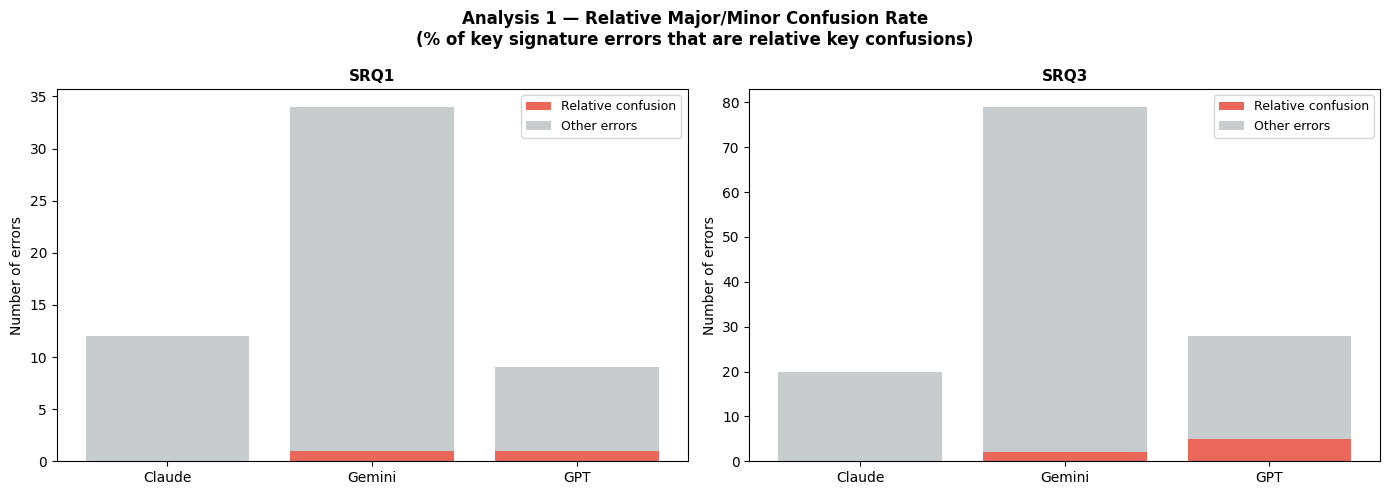

Saved to deep_1_relative_confusion.png


In [4]:
print("=" * 65)
print("ANALYSIS 1 — Relative Major/Minor Confusion")
print("=" * 65)

for srq_label, errors in [("SRQ1", errors_srq1), ("SRQ3", errors_srq3)]:
    n_errors   = len(errors)
    n_relative = errors["is_relative"].sum()
    pct        = n_relative / n_errors * 100 if n_errors > 0 else 0

    print(f"\n  {srq_label}:")
    print(f"    Total key sig errors: {n_errors}")
    print(f"    Relative confusion:   {n_relative} ({pct:.2f}% of errors)")

    print(f"\n    Per model:")
    for model in MODELS:
        sub   = errors[errors["model"] == model]
        n_e   = len(sub)
        n_rel = sub["is_relative"].sum()
        p     = n_rel / n_e * 100 if n_e > 0 else 0
        print(f"      {model:<25}: {n_rel}/{n_e} = {p:.2f}%")

    if n_relative > 0:
        print(f"\n    Relative confusion cases:")
        cases = errors[errors["is_relative"]][
            ["piece_id", "model", "true_norm", "pred_norm"]
        ]
        if "input_type" in errors.columns:
            cases = errors[errors["is_relative"]][
                ["piece_id", "model", "input_type", "true_norm", "pred_norm"]
            ]
        print(cases.to_string(index=False))

# ── PLOT ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Analysis 1 — Relative Major/Minor Confusion Rate\n"
    "(% of key signature errors that are relative key confusions)",
    fontsize=12, fontweight="bold"
)

for ax, (srq_label, errors) in zip(axes, [("SRQ1", errors_srq1), ("SRQ3", errors_srq3)]):
    model_data = []
    for model in MODELS:
        sub   = errors[errors["model"] == model]
        n_e   = len(sub)
        n_rel = sub["is_relative"].sum()
        model_data.append({
            "model": model.replace("claude-sonnet-4-6", "Claude")
                         .replace("gemini-2.5-flash", "Gemini")
                         .replace("gpt-5.4", "GPT"),
            "relative": n_rel,
            "other":    n_e - n_rel
        })
    mdf = pd.DataFrame(model_data)

    x = range(len(mdf))
    ax.bar(x, mdf["relative"], label="Relative confusion",
           color="#e74c3c", alpha=0.85)
    ax.bar(x, mdf["other"], bottom=mdf["relative"],
           label="Other errors", color="#bdc3c7", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(mdf["model"], fontsize=10)
    ax.set_ylabel("Number of errors", fontsize=10)
    ax.set_title(srq_label, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "deep_1_relative_confusion.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved to deep_1_relative_confusion.png")

does this mean that Claude understand music theory since it has 0% relative confusion within the errors output?

---
## Analysis 2 — Enharmonic Equivalence Errors + Relaxed Accuracy
F# major and Gb major are the same pitches — just spelled differently.
If a model predicts `Gb major` when the truth is `F# major`, is that
actually wrong from a musical standpoint?

We compute a **relaxed accuracy** that counts enharmonic equivalents as correct,
alongside the strict accuracy already computed.

In [5]:
print("=" * 65)
print("ANALYSIS 2 — Enharmonic Equivalence Errors")
print("=" * 65)

relaxed_records = []

for srq_label, df_srq in [("SRQ1", df1), ("SRQ3", df3)]:
    print(f"\n  {srq_label}:")
    df_key = df_srq[
        (df_srq["question_type"] == "key_signature") &
        (df_srq["model_response"] != "ERROR")
    ].copy()

    df_key["true_norm"] = df_key["ground_truth"].apply(
        lambda x: normalise_for_sklearn(x, "key_signature"))
    df_key["pred_norm"] = df_key["parsed_answer"].fillna("").apply(
        lambda x: normalise_for_sklearn(x, "key_signature"))

    # Relaxed correct = strict correct OR enharmonic equivalent
    df_key["enharmonic"] = df_key.apply(
        lambda r: (not r["correct"]) and
                   is_enharmonic(r["true_norm"], r["pred_norm"]), axis=1)
    df_key["relaxed_correct"] = df_key["correct"] | df_key["enharmonic"]

    # Group by model (and format if SRQ3)
    group_cols = ["model"] if srq_label == "SRQ1" else ["model", "input_type"]

    print(f"    {'model':<25} {'format':<6} {'strict_acc':>11} "
          f"{'enharmonic_n':>13} {'relaxed_acc':>12}")
    print("    " + "-" * 72)

    for keys, group in df_key.groupby(group_cols):
        if isinstance(keys, str):
            keys = (keys,)
        model  = keys[0]
        fmt    = keys[1] if len(keys) > 1 else "pdf"
        n      = len(group)
        strict = group["correct"].mean()
        n_enh  = group["enharmonic"].sum()
        relaxed= group["relaxed_correct"].mean()

        short_model = (model.replace("claude-sonnet-4-6", "Claude")
                           .replace("gemini-2.5-flash", "Gemini")
                           .replace("gpt-5.4", "GPT"))
        print(f"    {short_model:<25} {fmt:<6} "
              f"{strict:>11.3f} {n_enh:>13} {relaxed:>12.3f}")

        relaxed_records.append({
            "srq": srq_label, "model": model, "format": fmt,
            "n": n, "strict_acc": round(strict, 4),
            "n_enharmonic": int(n_enh),
            "relaxed_acc": round(relaxed, 4)
        })

    # Show which enharmonic errors occurred
    enh_cases = df_key[df_key["enharmonic"]][
        ["piece_id", "model", "true_norm", "pred_norm"]
    ]
    if len(enh_cases) > 0:
        print(f"\n    Enharmonic error cases ({len(enh_cases)} total):")
        print(enh_cases.to_string(index=False))
    else:
        print(f"\n    No enharmonic errors found — all errors are genuinely wrong.")

pd.DataFrame(relaxed_records).to_csv(
    RESULTS_DIR / "deep_2_relaxed_accuracy.csv", index=False)
print("\nSaved to deep_2_relaxed_accuracy.csv")

ANALYSIS 2 — Enharmonic Equivalence Errors

  SRQ1:
    model                     format  strict_acc  enharmonic_n  relaxed_acc
    ------------------------------------------------------------------------
    Claude                    pdf          0.810             0        0.810
    Gemini                    pdf          0.460             0        0.460
    GPT                       pdf          0.857             0        0.857

    No enharmonic errors found — all errors are genuinely wrong.

  SRQ3:
    model                     format  strict_acc  enharmonic_n  relaxed_acc
    ------------------------------------------------------------------------
    Claude                    pdf          0.794             0        0.794
    Claude                    png          0.889             0        0.889
    Gemini                    pdf          0.413             0        0.413
    Gemini                    png          0.333             0        0.333
    GPT                       pdf  

---
## Analysis 3 — Accidental Direction Errors (Sharp vs Flat confusion)
Keys can be classified as using sharps, flats, or neither.
If a model predicts a flat key when the truth is a sharp key (or vice versa),
it has misread the type of accidental — a more serious error than predicting
a nearby key in the same accidental direction.

ANALYSIS 3 — Accidental Direction Errors (Sharp vs Flat)

  SRQ1:
    Total errors:              55
    Same-direction errors:     34 (61.8%)
    Cross-direction errors:    21 (38.2%)

    Per model:
      claude-sonnet-4-6        : cross-dir 3/12 = 25.0%
      gemini-2.5-flash         : cross-dir 15/34 = 44.1%
      gpt-5.4                  : cross-dir 3/9 = 33.3%

    Cross-tabulation (true direction → predicted direction):
dir_pred  flat  natural  sharp
dir_true                      
flat        22        6      3
natural      3        0      6
sharp        1        2     12

  SRQ3:
    Total errors:              127
    Same-direction errors:     91 (71.7%)
    Cross-direction errors:    36 (28.3%)

    Per model:
      claude-sonnet-4-6        : cross-dir 4/20 = 20.0%
      gemini-2.5-flash         : cross-dir 24/79 = 30.4%
      gpt-5.4                  : cross-dir 8/28 = 28.6%

    Cross-tabulation (true direction → predicted direction):
dir_pred  flat  natural  sharp
dir_true 

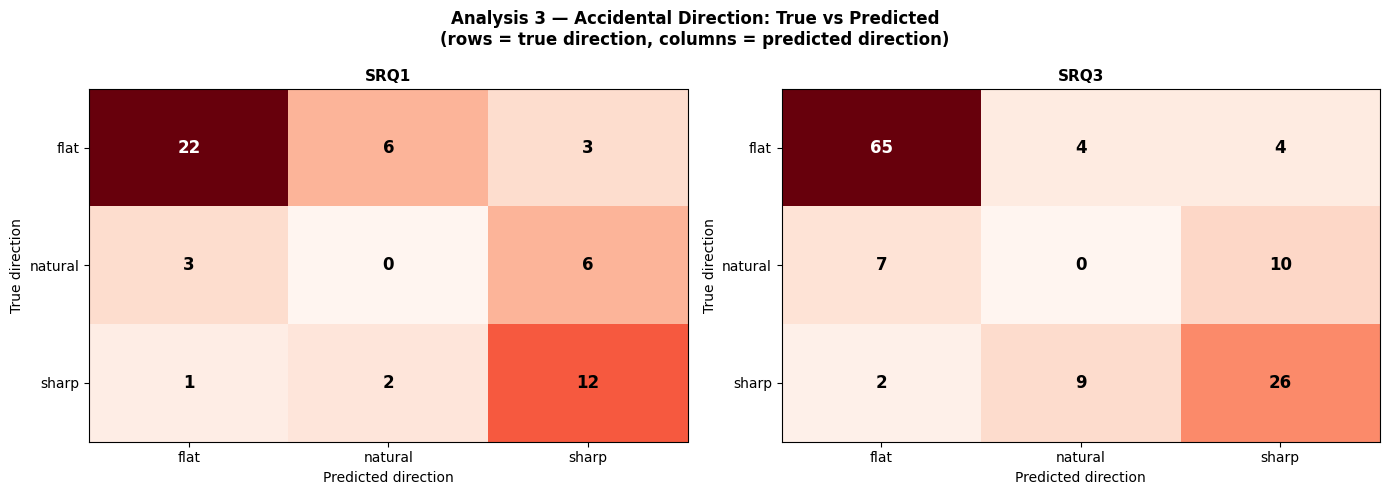

Saved to deep_3_direction_errors.png


In [6]:
print("=" * 65)
print("ANALYSIS 3 — Accidental Direction Errors (Sharp vs Flat)")
print("=" * 65)

direction_records = []

for srq_label, errors in [("SRQ1", errors_srq1), ("SRQ3", errors_srq3)]:
    n_errors    = len(errors)
    n_cross     = errors["dir_cross"].sum()
    n_same_dir  = n_errors - n_cross
    pct_cross   = n_cross / n_errors * 100 if n_errors > 0 else 0

    print(f"\n  {srq_label}:")
    print(f"    Total errors:              {n_errors}")
    print(f"    Same-direction errors:     {n_same_dir} ({100-pct_cross:.1f}%)")
    print(f"    Cross-direction errors:    {n_cross} ({pct_cross:.1f}%)")

    # Per-model breakdown
    print(f"\n    Per model:")
    for model in MODELS:
        sub     = errors[errors["model"] == model]
        n_e     = len(sub)
        n_cross_m = sub["dir_cross"].sum()
        p       = n_cross_m / n_e * 100 if n_e > 0 else 0
        print(f"      {model:<25}: cross-dir {n_cross_m}/{n_e} = {p:.1f}%")

    # Cross-tabulation: what direction was predicted when truth was sharp/flat?
    print(f"\n    Cross-tabulation (true direction → predicted direction):")
    ct = pd.crosstab(errors["dir_true"], errors["dir_pred"])
    print(ct.to_string())

    direction_records.append({
        "srq": srq_label,
        "n_errors": n_errors,
        "n_cross_direction": int(n_cross),
        "pct_cross": round(pct_cross, 2)
    })

# ── PLOT: direction confusion heatmap ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Analysis 3 — Accidental Direction: True vs Predicted\n"
    "(rows = true direction, columns = predicted direction)",
    fontsize=12, fontweight="bold"
)

for ax, (srq_label, errors) in zip(axes, [
    ("SRQ1", errors_srq1), ("SRQ3", errors_srq3)
]):
    ct = pd.crosstab(errors["dir_true"], errors["dir_pred"])
    # Ensure all direction categories are present
    for col in ["flat", "natural", "sharp", "unknown"]:
        if col not in ct.columns: ct[col] = 0
        if col not in ct.index:   ct.loc[col] = 0
    ct = ct.loc[
        [c for c in ["flat", "natural", "sharp"] if c in ct.index],
        [c for c in ["flat", "natural", "sharp"] if c in ct.columns]
    ]

    im = ax.imshow(ct.values, cmap="Reds", aspect="auto")
    ax.set_xticks(range(len(ct.columns)))
    ax.set_yticks(range(len(ct.index)))
    ax.set_xticklabels(ct.columns, fontsize=10)
    ax.set_yticklabels(ct.index, fontsize=10)
    ax.set_xlabel("Predicted direction", fontsize=10)
    ax.set_ylabel("True direction", fontsize=10)
    ax.set_title(srq_label, fontsize=11, fontweight="bold")

    for i in range(len(ct.index)):
        for j in range(len(ct.columns)):
            val = ct.values[i, j]
            colour = "white" if val > ct.values.max() * 0.6 else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=12, fontweight="bold", color=colour)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "deep_3_direction_errors.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved to deep_3_direction_errors.png")

---
## Analysis 4 — Circle of Fifths Error Distance
How far is the predicted key from the true key on the circle of fifths?

Distance 0 = same key (shouldn't appear in errors)
Distance 1 = adjacent keys (e.g. C major → G major, one step)
Distance 6 = maximum distance (opposite side of the circle)

Short distances = model is close but not exact.
Long distances = model is making unstructured guesses.

ANALYSIS 4 — Circle of Fifths Error Distance

  SRQ1:
    Errors with computable CoF distance: 52/55
    (Could not compute for 3 — unknown/unparsed keys)

    Distance distribution:
      Distance 0:   2  ██
      Distance 1:  30  ██████████████████████████████
      Distance 2:  10  ██████████
      Distance 3:   7  ███████
      Distance 4:   1  █
      Distance 5:   1  █
      Distance 6:   1  █

    Mean distance:   1.65
    Median distance: 1.0
    (Max possible:   6)

    Per model (mean CoF distance):
      claude-sonnet-4-6        : mean=1.20  (n=10)
      gemini-2.5-flash         : mean=1.91  (n=34)
      gpt-5.4                  : mean=1.12  (n=8)

  SRQ3:
    Errors with computable CoF distance: 121/127
    (Could not compute for 6 — unknown/unparsed keys)

    Distance distribution:
      Distance 0:   7  ███████
      Distance 1:  73  █████████████████████████████████████████████████████████████████████████
      Distance 2:  20  ████████████████████
      Distance 3:  17

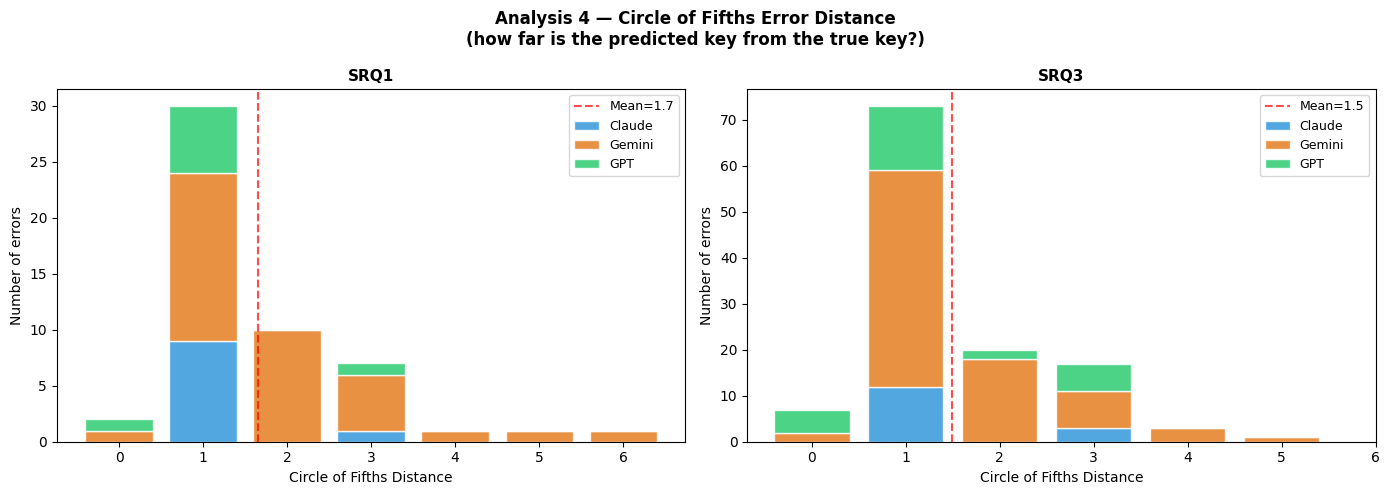

Saved to deep_4_cof_distance.png


In [7]:
print("=" * 65)
print("ANALYSIS 4 — Circle of Fifths Error Distance")
print("=" * 65)

cof_records = []

for srq_label, errors in [("SRQ1", errors_srq1), ("SRQ3", errors_srq3)]:
    valid = errors[errors["cof_dist"].notna()].copy()
    n_valid   = len(valid)
    n_unknown = len(errors) - n_valid

    print(f"\n  {srq_label}:")
    print(f"    Errors with computable CoF distance: {n_valid}/{len(errors)}")
    if n_unknown > 0:
        print(f"    (Could not compute for {n_unknown} — unknown/unparsed keys)")

    print(f"\n    Distance distribution:")
    dist_counts = valid["cof_dist"].value_counts().sort_index()
    for dist, count in dist_counts.items():
        bar = "█" * count
        print(f"      Distance {int(dist)}: {count:>3}  {bar}")

    mean_dist = valid["cof_dist"].mean()
    med_dist  = valid["cof_dist"].median()
    print(f"\n    Mean distance:   {mean_dist:.2f}")
    print(f"    Median distance: {med_dist:.1f}")
    print(f"    (Max possible:   6)")

    print(f"\n    Per model (mean CoF distance):")
    for model in MODELS:
        sub = valid[valid["model"] == model]
        if len(sub) == 0:
            print(f"      {model:<25}: no errors")
            continue
        md = sub["cof_dist"].mean()
        print(f"      {model:<25}: mean={md:.2f}  (n={len(sub)})")

    cof_records.append({
        "srq": srq_label,
        "mean_distance": round(mean_dist, 3),
        "median_distance": med_dist
    })

# ── PLOT: distance distribution ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Analysis 4 — Circle of Fifths Error Distance\n"
    "(how far is the predicted key from the true key?)",
    fontsize=12, fontweight="bold"
)

model_colours = {
    "claude-sonnet-4-6": "#3498db",
    "gemini-2.5-flash":  "#e67e22",
    "gpt-5.4":           "#2ecc71"
}
model_labels = {
    "claude-sonnet-4-6": "Claude",
    "gemini-2.5-flash":  "Gemini",
    "gpt-5.4":           "GPT"
}

for ax, (srq_label, errors) in zip(axes, [
    ("SRQ1", errors_srq1), ("SRQ3", errors_srq3)
]):
    valid = errors[errors["cof_dist"].notna()]

    # Stacked bar per distance, coloured by model
    dist_vals = sorted(valid["cof_dist"].unique())
    bottoms   = [0] * len(dist_vals)

    for model in MODELS:
        sub    = valid[valid["model"] == model]
        counts = [sub[sub["cof_dist"] == d].shape[0] for d in dist_vals]
        ax.bar([int(d) for d in dist_vals], counts,
               bottom=bottoms, label=model_labels[model],
               color=model_colours[model], alpha=0.85, edgecolor="white")
        bottoms = [b + c for b, c in zip(bottoms, counts)]

    ax.set_xlabel("Circle of Fifths Distance", fontsize=10)
    ax.set_ylabel("Number of errors", fontsize=10)
    ax.set_title(srq_label, fontsize=11, fontweight="bold")
    ax.set_xticks(range(7))
    ax.legend(fontsize=9)
    # Reference line at mean
    mean_d = valid["cof_dist"].mean()
    ax.axvline(mean_d, color="red", linestyle="--", alpha=0.7,
               label=f"Mean={mean_d:.1f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "deep_4_cof_distance.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved to deep_4_cof_distance.png")

---
## Analysis 5 — Per-Model Error Overlap (Shared Hard Movements)
Which movements does every model get wrong? If all three models fail on the same movement, it likely reflects genuine ambiguity or difficulty
in the sheet music — not a model-specific weakness. If only one model fails, it's that model's limitation.

We classify each (movement, task) pair into:
- **All wrong**: all 3 models incorrect
- **Two wrong**: 2 out of 3 incorrect
- **One wrong**: only 1 model incorrect
- **All correct**: all 3 correct

"Hard Movements"

- Def 1: all 3 models wrong.
- Def 2: We define a movement as a hard case if the majority of models (≥ 2 out of 3) produced an incorrect answer. This threshold was chosen because a single model failure may reflect model-specific limitations, whereas consistent failure across multiple models more plausibly reflects properties of the input itself — such as visual ambiguity in the notation or atypical key signature usage.

ANALYSIS 5 — Per-Model Error Overlap
Identifying movements that are hard for all vs one model

Definitions used:
  Hard      (Def 2): 2 or 3 models wrong
  Very hard (Def 1): all 3 models wrong

  SRQ1:

      key_signature:
        All correct:              23 / 63
        One wrong:                28 / 63
        Hard — Def 2 (2+ wrong):  12 / 63
        Very hard — Def 1 (all):   3 / 63
        Very hard movements (Def 1): ['03-3', '10-2', '31-3']
        2-wrong movements:           ['01-3', '06-1', '06-2', '06-3', '07-3', '07-4', '16-2', '18-2', '23-2']

      time_signature:
        All correct:              17 / 90
        One wrong:                61 / 90
        Hard — Def 2 (2+ wrong):  12 / 90
        Very hard — Def 1 (all):   1 / 90
        Very hard movements (Def 1): ['13-1']
        2-wrong movements:           ['01-4', '05-2', '08-3', '10-2', '16-2', '16-3', '20-1', '23-3', '29-1', '29-4', '30-3']

  SRQ3:

    Format: PDF

      key_signature:
        All correct:    

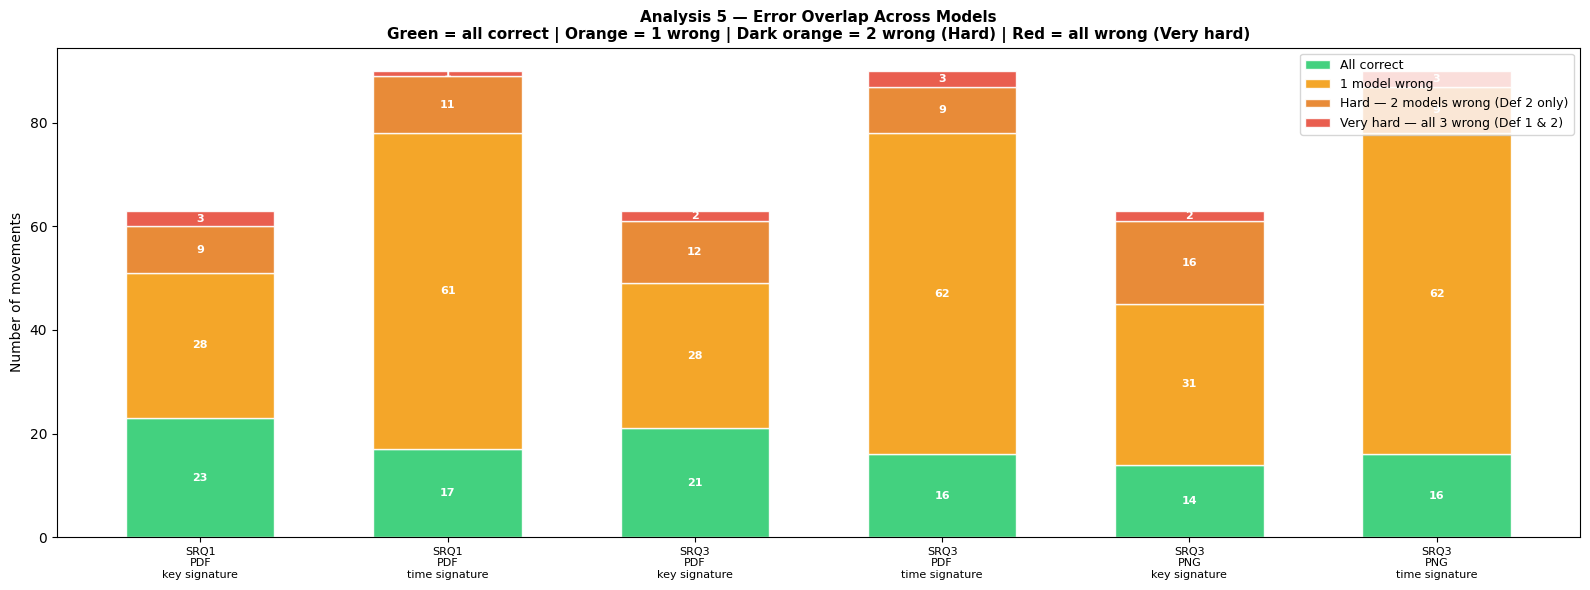


Saved to deep_5_error_overlap.png and .csv

Note: Discuss with supervisor which definition to use in thesis.
  Definition 1 (all wrong)  — strictest, most conservative
  Definition 2 (2+ wrong)   — majority-based, more inclusive


In [8]:
print("=" * 65)
print("ANALYSIS 5 — Per-Model Error Overlap")
print("Identifying movements that are hard for all vs one model")
print("=" * 65)
print()
print("Definitions used:")
print("  Hard      (Def 2): 2 or 3 models wrong")
print("  Very hard (Def 1): all 3 models wrong")

overlap_records = []

for srq_label, df_srq in [("SRQ1", df1), ("SRQ3", df3)]:
    print(f"\n  {srq_label}:")

    format_list = ["pdf", "png"] if srq_label == "SRQ3" else ["pdf"]

    for fmt in format_list:
        df_fmt = df_srq[df_srq["input_type"] == fmt] if srq_label == "SRQ3" else df_srq

        if srq_label == "SRQ3":
            print(f"\n    Format: {fmt.upper()}")

        for task in TASKS:
            df_task = df_fmt[
                (df_fmt["question_type"] == task) &
                (df_fmt["model_response"] != "ERROR")
            ]

            movements        = df_task["piece_id"].unique()
            all_correct_list = []
            one_wrong        = []
            two_wrong        = []
            all_wrong        = []

            for mid in movements:
                df_mov = df_task[df_task["piece_id"] == mid]

                model_correct = {}
                for model in MODELS:
                    row = df_mov[df_mov["model"] == model]
                    if not row.empty:
                        model_correct[model] = bool(row.iloc[0]["correct"])

                if len(model_correct) < 3:
                    continue

                n_correct = sum(model_correct.values())
                n_wrong   = 3 - n_correct

                overlap_records.append({
                    "srq":            srq_label,
                    "format":         fmt,
                    "task":           task,
                    "piece_id":       mid,
                    "n_wrong":        n_wrong,
                    "claude_correct": model_correct.get("claude-sonnet-4-6"),
                    "gemini_correct": model_correct.get("gemini-2.5-flash"),
                    "gpt_correct":    model_correct.get("gpt-5.4")
                })

                if n_wrong == 3:   all_wrong.append(mid)
                elif n_wrong == 2: two_wrong.append(mid)
                elif n_wrong == 1: one_wrong.append(mid)
                else:              all_correct_list.append(mid)

            # Two-tier hard definition
            hard_movements      = two_wrong + all_wrong  # Definition 2
            very_hard_movements = all_wrong              # Definition 1

            total_movs = len(movements)
            print(f"\n      {task}:")
            print(f"        All correct:             {len(all_correct_list):>3} / {total_movs}")
            print(f"        One wrong:               {len(one_wrong):>3} / {total_movs}")
            print(f"        Hard — Def 2 (2+ wrong): {len(hard_movements):>3} / {total_movs}")
            print(f"        Very hard — Def 1 (all): {len(very_hard_movements):>3} / {total_movs}")

            if very_hard_movements:
                print(f"        Very hard movements (Def 1): {sorted(very_hard_movements)}")
            if two_wrong:
                print(f"        2-wrong movements:           {sorted(two_wrong)}")

# ── PLOT ──────────────────────────────────────────────────────────────────────

overlap_df = pd.DataFrame(overlap_records)

plot_data = []
for srq_label in ["SRQ1", "SRQ3"]:
    sub_srq = overlap_df[overlap_df["srq"] == srq_label]

    format_task_pairs = (
        [("pdf", task) for task in TASKS] if srq_label == "SRQ1"
        else [(fmt, task) for fmt in ["pdf", "png"] for task in TASKS]
    )

    for fmt, task in format_task_pairs:
        group = sub_srq[
            (sub_srq["format"] == fmt) &
            (sub_srq["task"] == task)
        ]
        if group.empty:
            continue

        counts = group["n_wrong"].value_counts()
        label  = f"{srq_label}\n{fmt.upper()}\n{task.replace('_', ' ')}"
        plot_data.append({
            "label":       label,
            "all_correct": counts.get(0, 0),
            "one_wrong":   counts.get(1, 0),
            "two_wrong":   counts.get(2, 0),
            "all_wrong":   counts.get(3, 0)
        })

plot_df = pd.DataFrame(plot_data)

fig, ax = plt.subplots(figsize=(16, 6))
x       = np.arange(len(plot_df))
width   = 0.6

# Stack order: all correct → one wrong → two wrong → all wrong
stack_cols   = ["all_correct", "one_wrong", "two_wrong", "all_wrong"]
stack_colours = ["#2ecc71",    "#f39c12",   "#e67e22",   "#e74c3c"]
stack_labels  = [
    "All correct",
    "1 model wrong",
    "Hard — 2 models wrong (Def 2 only)",
    "Very hard — all 3 wrong (Def 1 & 2)"
]

bottoms = [0] * len(plot_df)
for col, colour, label in zip(stack_cols, stack_colours, stack_labels):
    vals = plot_df[col].values
    ax.bar(x, vals, width, bottom=bottoms,
           color=colour, label=label, alpha=0.9, edgecolor="white")
    # Value labels inside bars (only if bar is tall enough)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0:
            ax.text(x[i], b + v / 2, str(v),
                    ha="center", va="center", fontsize=8,
                    fontweight="bold", color="white")
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], fontsize=8)
ax.set_ylabel("Number of movements", fontsize=10)
ax.set_title(
    "Analysis 5 — Error Overlap Across Models\n"
    "Green = all correct | Orange = 1 wrong | "
    "Dark orange = 2 wrong (Hard) | Red = all wrong (Very hard)",
    fontsize=11, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "deep_5_error_overlap.png", dpi=130, bbox_inches="tight")
plt.show()

overlap_df.to_csv(RESULTS_DIR / "deep_5_error_overlap.csv", index=False)
print("\nSaved to deep_5_error_overlap.png and .csv")
print("\nNote: Discuss with supervisor which definition to use in thesis.")
print("  Definition 1 (all wrong)  — strictest, most conservative")
print("  Definition 2 (2+ wrong)   — majority-based, more inclusive")

---
## All deep analysis outputs saved to `results/`

| File | Content |
|------|---------|
| `deep_1_relative_confusion.png` | Relative major/minor confusion per model |
| `deep_2_relaxed_accuracy.csv` | Strict vs relaxed (enharmonic) accuracy |
| `deep_3_direction_errors.png` | Sharp/flat direction confusion heatmap |
| `deep_4_cof_distance.png` | Circle of fifths error distance distribution |
| `deep_5_error_overlap.png/.csv` | Error overlap — which movements all models fail on |

---
**Interpretation notes:**
- Analysis 1: If relative confusion is high → models read accidentals but not modality
- Analysis 2: If relaxed accuracy ≈ strict accuracy → enharmonic errors are rare/absent
- Analysis 3: Diagonal = same direction (less severe); off-diagonal = direction confusion (more severe)
- Analysis 4: Short mean distance → model is close but not exact; long distance → random guessing
- Analysis 5: Movements where all models fail = dataset difficulty; single-model failures = model weakness

### Gemini prior bias analysis

Goal: Check whether Gemini has a strong output prior — predicting certain classes (e.g. 4/4) disproportionately often regardless of what the input actually shows.Steps:

1. Get Gemini's predicted class distribution vs ground truth distribution
2. Do the same for Claude and GPT as a comparison baseline
3. Run a chi-square test to check if Gemini's prediction distribution is significantly different from the ground truth distribution
4. Visualise side by side

ANALYSIS 6 — Output Prior Bias (Predicted Class Distribution)
Does Gemini predict certain classes disproportionately often,
regardless of what the input actually shows?

  SRQ1

  Task: key_signature
  --------------------------------------------------

  Ground truth distribution (16 classes):
    a major                  2  (  3.2%)  █
    ab major                 5  (  7.9%)  ███
    bb major                 1  (  1.6%)  
    c major                  8  ( 12.7%)  ██████
    c minor                  5  (  7.9%)  ███
    d major                  4  (  6.3%)  ███
    d minor                  3  (  4.8%)  ██
    db major                 1  (  1.6%)  
    e major                  5  (  7.9%)  ███
    e minor                  2  (  3.2%)  █
    eb major                 6  (  9.5%)  ████
    f major                  4  (  6.3%)  ███
    f minor                  7  ( 11.1%)  █████
    f# major                 2  (  3.2%)  █
    g major                  7  ( 11.1%)  █████
    g minor        

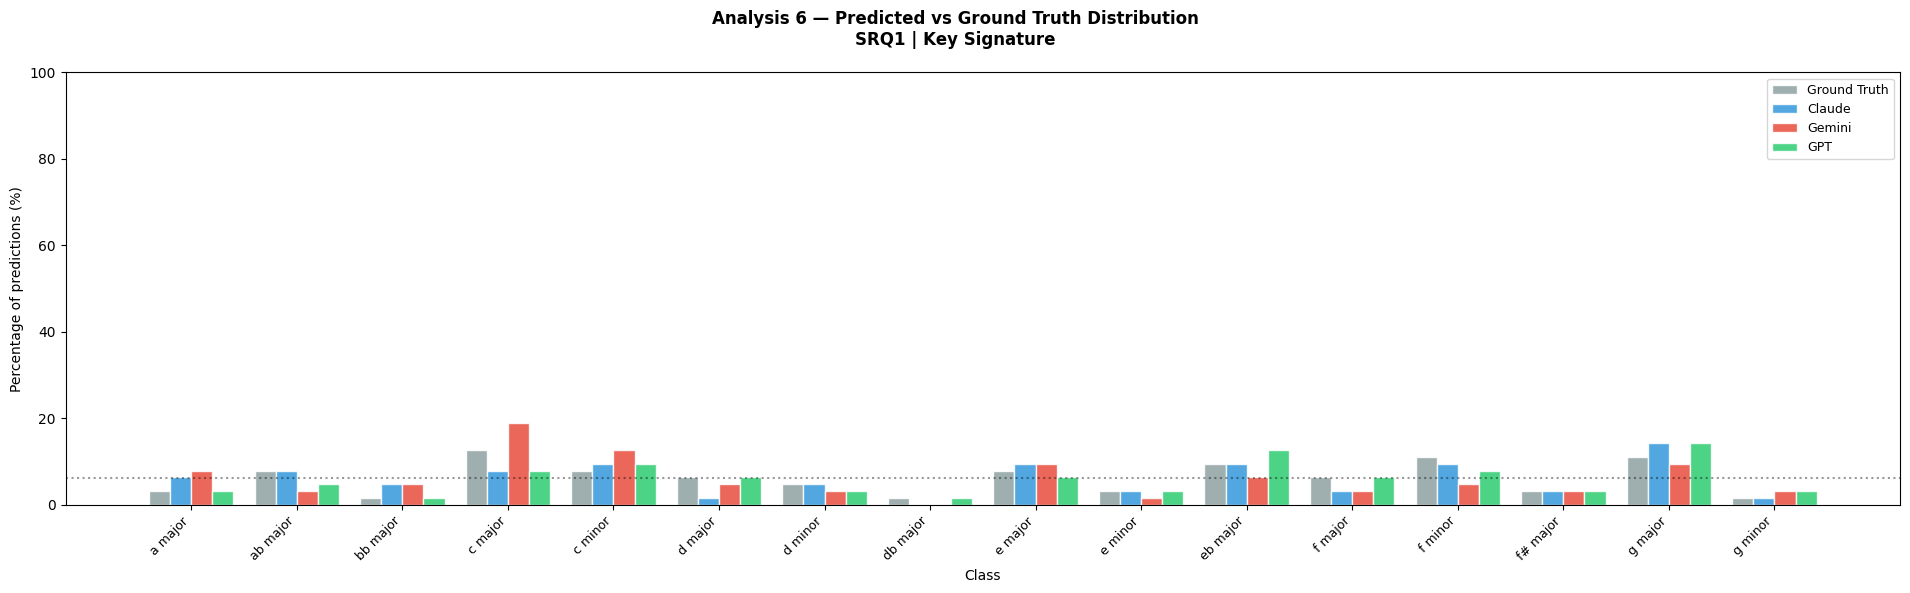

Saved to deep_6_prior_bias_key_signature.png


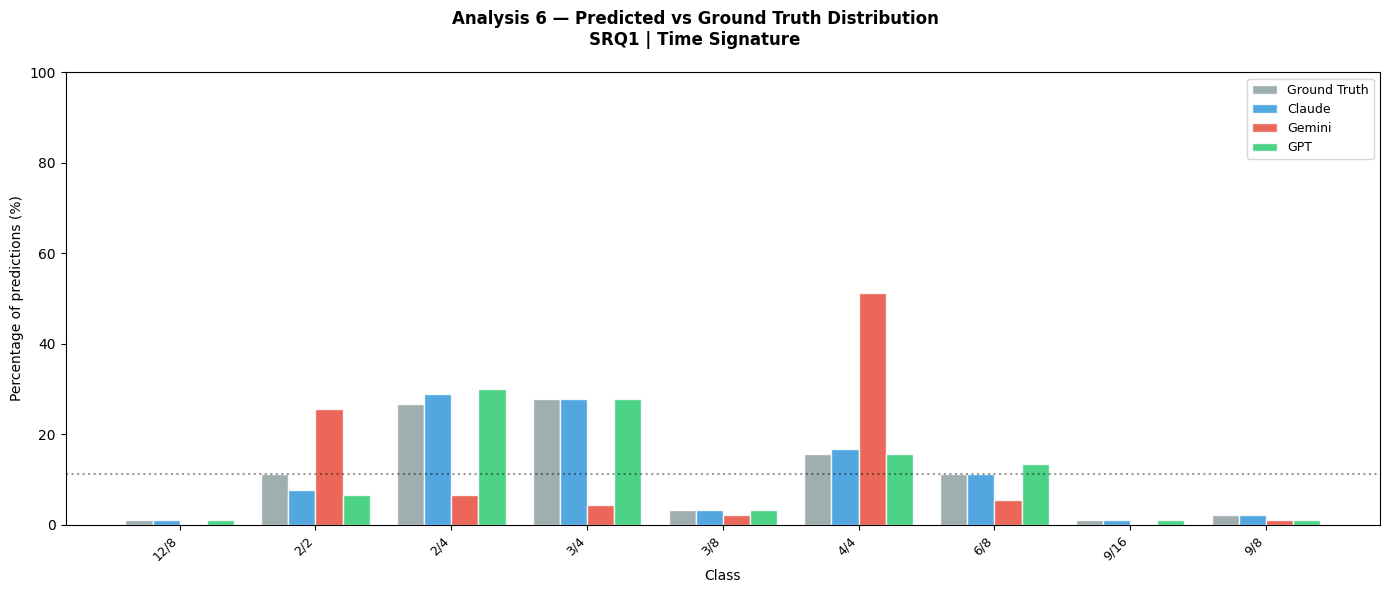

Saved to deep_6_prior_bias_time_signature.png


Summary — Chi-square significance across all conditions:
srq          model                     task                        p   sig
---------------------------------------------------------------------------
SRQ1         claude-sonnet-4-6         key_signature          0.8964    ns
SRQ1         gemini-2.5-flash          key_signature          0.1610    ns
SRQ1         gpt-5.4                   key_signature          0.6470    ns
SRQ1         claude-sonnet-4-6         time_signature         0.8882    ns
SRQ1         gemini-2.5-flash          time_signature         0.0000   ***
SRQ1         gpt-5.4                   time_signature         0.6744    ns
SRQ3 PDF     claude-sonnet-4-6         key_signature          0.7153    ns
SRQ3 PDF     gemini-2.5-flash          key_signature          0.0124     *
SRQ3 PDF     gpt-5.4                   key_signature          0.8019    ns
SRQ3 PDF     claude-sonnet-4-6         time_signature         0.6288 

In [9]:
from scipy.stats import chisquare
import warnings
warnings.filterwarnings("ignore")

print("=" * 65)
print("ANALYSIS 6 — Output Prior Bias (Predicted Class Distribution)")
print("Does Gemini predict certain classes disproportionately often,")
print("regardless of what the input actually shows?")
print("=" * 65)

# ── HELPER ────────────────────────────────────────────────────────────────────

def analyse_prior_bias(df, srq_label):
    """
    For each model and task, compare:
    - Ground truth class distribution (what the data actually contains)
    - Predicted class distribution (what the model actually outputs)

    A biased model will have a predicted distribution that diverges
    significantly from the ground truth distribution.
    Chi-square goodness-of-fit tests whether the predicted distribution
    matches the ground truth distribution.
    """
    print(f"\n{'='*55}")
    print(f"  {srq_label}")
    print(f"{'='*55}")

    bias_records = []

    for task in TASKS:
        print(f"\n  Task: {task}")
        print(f"  {'-'*50}")

        df_task = df[
            (df["question_type"] == task) &
            (df["model_response"] != "ERROR")
        ].copy()

        df_task["true_norm"] = df_task["ground_truth"].apply(
            lambda x: normalise_for_sklearn(x, task))
        df_task["pred_norm"] = df_task["parsed_answer"].fillna("unknown").apply(
            lambda x: normalise_for_sklearn(x, task))

        # Ground truth distribution — same for all models
        gt_dist = df_task[df_task["model"] == MODELS[0]]["true_norm"].value_counts()
        all_classes = sorted(gt_dist.index.tolist())

        print(f"\n  Ground truth distribution ({len(all_classes)} classes):")
        for cls in all_classes:
            count = gt_dist.get(cls, 0)
            pct   = count / gt_dist.sum() * 100
            bar   = "█" * int(pct / 2)
            print(f"    {cls:<22} {count:>3}  ({pct:>5.1f}%)  {bar}")

        for model in MODELS:
            df_model = df_task[df_task["model"] == model]
            pred_dist = df_model["pred_norm"].value_counts()
            n_total   = len(df_model)

            print(f"\n  {model} — predicted distribution:")
            for cls in all_classes:
                gt_count   = gt_dist.get(cls, 0)
                pred_count = pred_dist.get(cls, 0)
                pct_gt     = gt_count / gt_dist.sum() * 100
                pct_pred   = pred_count / n_total * 100
                delta      = pct_pred - pct_gt
                bar        = "█" * int(pct_pred / 2)
                flag       = " ◄ OVER-PREDICTED" if delta > 15 else \
                             " ◄ under-predicted" if delta < -15 else ""
                print(f"    {cls:<22} pred={pred_count:>3} ({pct_pred:>5.1f}%) "
                      f"| gt={gt_count:>3} ({pct_gt:>5.1f}%) "
                      f"| Δ={delta:>+6.1f}pp{flag}")

            # Check for predictions outside the ground truth label set
            unknown_preds = df_model[
                ~df_model["pred_norm"].isin(all_classes)
            ]["pred_norm"].value_counts()
            if len(unknown_preds) > 0:
                print(f"    Predictions outside GT label set: "
                      f"{unknown_preds.to_dict()}")

            # ── CHI-SQUARE TEST ───────────────────────────────────────────────
            # H0: the model's predicted distribution matches
            #     the ground truth distribution

            observed = [pred_dist.get(cls, 0) for cls in all_classes]
            gt_props = [gt_dist.get(cls, 0) / gt_dist.sum()
                        for cls in all_classes]
            expected = [p * n_total for p in gt_props]

            # Filter out cells where expected < 5 (chi-square assumption)
            valid_pairs = [(o, e) for o, e in zip(observed, expected) if e >= 5]

            if len(valid_pairs) >= 2:
                obs_valid = [v[0] for v in valid_pairs]
                exp_valid = [v[1] for v in valid_pairs]

                # Rescale expected to match observed sum exactly
                # (required after dropping small cells)
                obs_sum   = sum(obs_valid)
                exp_sum   = sum(exp_valid)
                exp_valid = [e * (obs_sum / exp_sum) for e in exp_valid]

                chi2, p = chisquare(obs_valid, f_exp=exp_valid)
                sig     = ("***" if p < 0.001 else
                        "**"  if p < 0.01  else
                        "*"   if p < 0.05  else "ns")
                n_merged = len(all_classes) - len(valid_pairs)
                note     = f" ({n_merged} small cells merged)" \
                        if n_merged > 0 else ""
                print(f"\n    Chi-square test{note}:")
                print(f"    χ²={chi2:.3f}, p={p:.4f}  {sig}")
                print(f"    → {'Predicted distribution DIFFERS significantly '
                            'from ground truth (prior bias likely)'
                            if p < 0.05 else
                            'No significant divergence from ground truth'}")
            else:
                chi2, p, sig = float("nan"), float("nan"), "n/a"
                print(f"    Chi-square test: not enough valid cells to compute")

            bias_records.append({
                "srq":          srq_label,
                "model":        model,
                "task":         task,
                "n":            n_total,
                "chi2":         round(chi2, 4) if not pd.isna(chi2) else None,
                "p_value":      round(p, 4)    if not pd.isna(p)    else None,
                "significant":  sig,
                "top_predicted": pred_dist.index[0] if len(pred_dist) > 0
                                 else "unknown",
                "top_gt":        gt_dist.index[0] if len(gt_dist) > 0
                                 else "unknown"
            })

    return pd.DataFrame(bias_records)


# ── RUN ON BOTH SRQs ──────────────────────────────────────────────────────────

bias_srq1 = analyse_prior_bias(df1, "SRQ1")
bias_srq3_pdf = analyse_prior_bias(
    df3[df3["input_type"] == "pdf"], "SRQ3 PDF")
bias_srq3_png = analyse_prior_bias(
    df3[df3["input_type"] == "png"], "SRQ3 PNG")

bias_all = pd.concat([bias_srq1, bias_srq3_pdf, bias_srq3_png],
                      ignore_index=True)


# ── PLOT — side-by-side distributions for SRQ1 ───────────────────────────────
# One figure per task, showing GT vs each model's predicted distribution

print("\n\nGenerating distribution comparison plots...")

for task in TASKS:
    df_task = df1[
        (df1["question_type"] == task) &
        (df1["model_response"] != "ERROR")
    ].copy()

    df_task["true_norm"] = df_task["ground_truth"].apply(
        lambda x: normalise_for_sklearn(x, task))
    df_task["pred_norm"] = df_task["parsed_answer"].fillna("unknown").apply(
        lambda x: normalise_for_sklearn(x, task))

    gt_dist    = df_task[df_task["model"] == MODELS[0]]["true_norm"] \
                 .value_counts().sort_index()
    all_classes = sorted(gt_dist.index.tolist())
    n_classes   = len(all_classes)
    x           = np.arange(n_classes)
    bar_width   = 0.2

    fig, ax = plt.subplots(figsize=(max(14, n_classes * 1.2), 6))
    fig.suptitle(
        f"Analysis 6 — Predicted vs Ground Truth Distribution\n"
        f"SRQ1 | {task.replace('_', ' ').title()}",
        fontsize=12, fontweight="bold"
    )

    model_colours = {
        "claude-sonnet-4-6": "#3498db",
        "gemini-2.5-flash":  "#e74c3c",
        "gpt-5.4":           "#2ecc71"
    }
    model_labels = {
        "claude-sonnet-4-6": "Claude",
        "gemini-2.5-flash":  "Gemini",
        "gpt-5.4":           "GPT"
    }

    # Ground truth bar
    gt_counts = [gt_dist.get(cls, 0) for cls in all_classes]
    gt_total  = sum(gt_counts)
    gt_pcts   = [c / gt_total * 100 for c in gt_counts]
    ax.bar(x - 1.5 * bar_width, gt_pcts, bar_width,
           label="Ground Truth", color="#95a5a6",
           alpha=0.9, edgecolor="white")

    # One bar per model
    for i, model in enumerate(MODELS):
        df_model  = df_task[df_task["model"] == model]
        pred_dist = df_model["pred_norm"].value_counts()
        n_total   = len(df_model)
        pred_pcts = [pred_dist.get(cls, 0) / n_total * 100
                     for cls in all_classes]
        offset    = (i - 0.5) * bar_width
        ax.bar(x + offset, pred_pcts, bar_width,
               label=model_labels[model],
               color=model_colours[model],
               alpha=0.85, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(all_classes, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Percentage of predictions (%)", fontsize=10)
    ax.set_xlabel("Class", fontsize=10)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 100)
    ax.axhline(100 / n_classes, color="black", linestyle=":",
               alpha=0.4, label="Chance level")

    plt.tight_layout()
    out_path = RESULTS_DIR / f"deep_6_prior_bias_{task}.png"
    plt.savefig(out_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved to deep_6_prior_bias_{task}.png")


# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────

print("\n\nSummary — Chi-square significance across all conditions:")
print(f"{'srq':<12} {'model':<25} {'task':<20} {'p':>8} {'sig':>5}")
print("-" * 75)
for _, row in bias_all.iterrows():
    p_str = f"{row['p_value']:.4f}" if row["p_value"] is not None else "n/a"
    print(f"{row['srq']:<12} {row['model']:<25} "
          f"{row['task']:<20} {p_str:>8} {row['significant']:>5}")

bias_all.to_csv(RESULTS_DIR / "deep_6_prior_bias.csv", index=False)
print(f"\nSaved to deep_6_prior_bias.csv")
print("\nNote: A significant chi-square (p < .05) means the model's predicted")
print("class distribution differs from the ground truth distribution —")
print("evidence of output prior bias rather than genuine notation reading.")

---
## Analysis 7b — Shared Failure Modes Between Models (SRQ1)

The Cohen's κ analysis above measures pairwise agreement across all
answers, but for a task with a single ground truth, agreement primarily
reflects shared correctness rather than meaningful inter-model
convergence — better models will inevitably agree more.

This cell addresses that limitation by restricting the analysis to
**cases where both models in a pair produced a wrong answer**. Among
those joint failures, we ask: did the models fail in the *same way*?

Three views are reported per (task, model pair):

1. **Exact match rate** — fraction of joint failures where both models
   gave literally the same wrong answer (e.g. both said "Bb major").
2. **Accidental-count match rate** (key signature only) — fraction
   where the two wrong answers correspond to the same number of
   sharps/flats. Captures *relative-key confusion* (e.g. one model
   said "Bb major" and the other said "G minor" — both indicate
   2 flats, so they share the visual perception of the key signature
   but disagree on major vs minor).
3. **Breakdown of the actual shared wrong-answer pairs** — the most
   frequent (model A's answer, model B's answer) combinations, with
   counts and the movement IDs where they occurred. Useful for
   identifying specific recurring confusions to discuss in the
   results chapter.

**Interpretation guide:**
- High exact-match rate → models share a systematic bias and fail in
  identical ways.
- Low exact-match but high accidental-count match → models share the
  *visual* failure (perceive the same number of accidentals) but
  diverge on mode interpretation.
- Both low → failures are idiosyncratic, no systematic shared bias.

In [10]:
# Define MODEL_PAIRS locally in case the kappa cell above hasn't been run yet
MODEL_PAIRS = [
    ('claude-sonnet-4-6', 'gemini-2.5-flash', 'Claude vs Gemini'),
    ('claude-sonnet-4-6', 'gpt-5.4',          'Claude vs GPT'),
    ('gemini-2.5-flash',  'gpt-5.4',          'Gemini vs GPT'),
]

In [11]:
# ── ANALYSIS — SRQ1: Shared Failure Modes Between Models ──────────────────────
# When two models both got an answer WRONG on the same movement,
# did they give the same wrong answer? This addresses the limitation
# that naive Cohen's kappa primarily reflects shared correctness rather
# than meaningful cross-model agreement.
#
# Three views:
#   1. Exact match — both models gave literally the same wrong answer
#   2. Accidental-count match (key signature only) — both wrong answers
#      share the same accidental count (e.g. relative key confusion)
#   3. Breakdown of the actual shared wrong answers, with counts.

print('=' * 70)
print('ANALYSIS — SRQ1: Shared Failure Modes Between Models')
print('When two models both got it wrong, did they fail the same way?')
print('=' * 70)

# ── ACCIDENTAL-COUNT LOOKUP ───────────────────────────────────────────────────
# Sharps positive, flats negative. Relative-key pairs share a value.
ACCIDENTAL_COUNT = {
    'c major':  0, 'a minor':  0,
    'g major':  1, 'e minor':  1,
    'd major':  2, 'b minor':  2,
    'a major':  3, 'f# minor':  3,
    'e major':  4, 'c# minor':  4,
    'b major':  5, 'g# minor':  5,
    'f# major': 6, 'd# minor':  6,
    'f major': -1, 'd minor': -1,
    'bb major':-2, 'g minor': -2,
    'eb major':-3, 'c minor': -3,
    'ab major':-4, 'f minor': -4,
    'db major':-5, 'bb minor':-5,
    'gb major':-6, 'eb minor':-6,
}

shared_failure_records = []
breakdown_records      = []

for task in TASKS:
    df_task = df1[
        (df1['question_type'] == task) &
        (df1['model_response'] != 'ERROR')
    ].copy()
    df_task['pred_norm'] = df_task['parsed_answer'].fillna('unknown').apply(
        lambda x: normalise_for_sklearn(x, task))

    print(f'\n  {"─" * 64}')
    print(f'  Task: {task}')
    print(f'  {"─" * 64}')

    for model_a, model_b, pair_label in MODEL_PAIRS:
        # Wide table: one row per movement, with both models' answers + correctness
        df_a = df_task[df_task['model'] == model_a].set_index('piece_id')[
            ['pred_norm', 'correct']
        ].rename(columns={'pred_norm': 'pred_a', 'correct': 'correct_a'})
        df_b = df_task[df_task['model'] == model_b].set_index('piece_id')[
            ['pred_norm', 'correct']
        ].rename(columns={'pred_norm': 'pred_b', 'correct': 'correct_b'})
        merged = df_a.join(df_b, how='inner')

        # Restrict to BOTH-WRONG cases — the population Christoph asked about
        both_wrong = merged[(~merged['correct_a']) & (~merged['correct_b'])]
        n_both_wrong = len(both_wrong)

        if n_both_wrong == 0:
            print(f'\n    {pair_label}: no both-wrong cases — skipped')
            continue

        # ── View 1: exact match on wrong answer ──────────────────────────────
        exact_match = (both_wrong['pred_a'] == both_wrong['pred_b']).sum()
        exact_rate  = exact_match / n_both_wrong

        # ── View 2: accidental-count match (key signature only) ──────────────
        accidental_match = None
        accidental_rate  = None
        if task == 'key_signature':
            def _accs(x):
                return ACCIDENTAL_COUNT.get(x, None)
            counts_a = both_wrong['pred_a'].apply(_accs)
            counts_b = both_wrong['pred_b'].apply(_accs)
            # Only count when BOTH predictions are mappable to an accidental count
            both_mappable = counts_a.notna() & counts_b.notna()
            if both_mappable.any():
                accidental_match = (
                    (counts_a == counts_b) & both_mappable
                ).sum()
                accidental_rate = accidental_match / both_mappable.sum()

        print(f'\n    {pair_label}')
        print(f'      Both-wrong cases:          {n_both_wrong}')
        print(f'      Same exact wrong answer:   {exact_match}/{n_both_wrong} '
              f'= {exact_rate:.1%}')
        if accidental_match is not None:
            print(f'      Same accidental count:     '
                  f'{accidental_match}/{int(both_mappable.sum())} '
                  f'= {accidental_rate:.1%} (relative-key family)')

        shared_failure_records.append({
            'task':              task,
            'pair':              pair_label,
            'n_both_wrong':      n_both_wrong,
            'exact_match':       int(exact_match),
            'exact_match_rate':  round(exact_rate, 4),
            'accidental_match':  int(accidental_match) if accidental_match is not None else None,
            'accidental_rate':   round(accidental_rate, 4) if accidental_rate is not None else None,
        })

        # ── View 3: actual shared wrong-answer pairs ─────────────────────────
        # Pairs of (model_a_answer, model_b_answer) with counts and movement IDs
        pair_counts = (
            both_wrong.groupby(['pred_a', 'pred_b'])
            .apply(lambda g: {
                'n': len(g),
                'movements': sorted(g.index.tolist())
            })
            .to_dict()
        )

        if pair_counts:
            # Sort by count descending
            sorted_pairs = sorted(
                pair_counts.items(),
                key=lambda kv: kv[1]['n'],
                reverse=True
            )
            print(f'\n      Top shared wrong-answer patterns:')
            print(f'      {"model_a says":<18} {"model_b says":<18} {"n":>3}   movements')
            for (pred_a, pred_b), info in sorted_pairs[:8]:
                same = '✓' if pred_a == pred_b else ' '
                movement_preview = ', '.join(info['movements'][:5])
                if len(info['movements']) > 5:
                    movement_preview += f' (+{len(info["movements"]) - 5} more)'
                print(f'      {pred_a:<18} {pred_b:<18} {info["n"]:>3} {same} {movement_preview}')

                breakdown_records.append({
                    'task':         task,
                    'pair':         pair_label,
                    'model_a_pred': pred_a,
                    'model_b_pred': pred_b,
                    'same_answer':  pred_a == pred_b,
                    'n':            info['n'],
                    'movements':    '; '.join(info['movements']),
                })

# ── SAVE ──────────────────────────────────────────────────────────────────────
shared_df    = pd.DataFrame(shared_failure_records)
breakdown_df = pd.DataFrame(breakdown_records)

shared_df.to_csv(RESULTS_DIR / 'srq1_shared_failures.csv', index=False)
breakdown_df.to_csv(RESULTS_DIR / 'srq1_shared_failures_breakdown.csv', index=False)

print('\n' + '=' * 70)
print('Summary table:')
print('=' * 70)
print(shared_df.to_string(index=False))

print('\nSaved to:')
print('  srq1_shared_failures.csv            — headline rates per (task, pair)')
print('  srq1_shared_failures_breakdown.csv  — actual answer-pair counts')

print('\nInterpretation:')
print('  High exact-match rate → models fail the same way (shared bias)')
print('  Low exact-match rate but high accidental-match rate →')
print('    models share the visual confusion (same accidental count seen)')
print('    but differ on mode (major/minor) interpretation')
print('  Both low → failures are idiosyncratic, no systematic shared bias')

ANALYSIS — SRQ1: Shared Failure Modes Between Models
When two models both got it wrong, did they fail the same way?

  ────────────────────────────────────────────────────────────────
  Task: key_signature
  ────────────────────────────────────────────────────────────────

    Claude vs Gemini
      Both-wrong cases:          8
      Same exact wrong answer:   2/8 = 25.0%
      Same accidental count:     2/7 = 28.6% (relative-key family)

      Top shared wrong-answer patterns:
      model_a says       model_b says         n   movements
      a major            a major              1 ✓ 07-3
      a major            e major              1   07-4
      ab major           ab major             1 ✓ 23-2
      ab minor           c minor              1   31-3
      bb major           c major              1   06-3
      bb major           g major              1   06-1
      c minor            a major              1   03-3
      g major            f major              1   10-2

    Claude vs GP

---
## Analysis 7c — Ground Truth for Shared Failures (SRQ1)

Analysis 7b showed that Claude and GPT share an unusually high
exact-match rate on key-signature failures (4/4 = 100%). To
characterise *what* those shared confusions actually are, this cell
pulls the ground truth for every joint-failure case in each
model pair and tabulates the (truth → predicted) error patterns.

For key signatures, we additionally compute the **accidental-count
delta** between truth and prediction, which characterises the
structure of the error:

- **Delta = 0** with same mode → exact match (shouldn't happen — these are wrong answers)
- **Delta = 0** with different mode → *relative-key confusion* (same key signature, major ↔ minor)
- **|Delta| = 1** → *adjacent-key confusion* (one accidental too many or too few)
- **Larger |Delta|** → unstructured visual error

Each row also lists the specific movement IDs so individual cases
can be inspected in the score for the discussion section.

In [12]:
# ── ANALYSIS 7c — Ground Truth for Shared Failures (SRQ1) ─────────────────────
# Pulls ground truth for each joint-failure case and characterises
# the structure of shared confusions.

print('=' * 70)
print('ANALYSIS 7c — Ground Truth for Shared Failures (SRQ1)')
print('What were the actual confusions in joint-failure cases?')
print('=' * 70)

gt_records = []

for task in TASKS:
    df_task = df1[
        (df1['question_type'] == task) &
        (df1['model_response'] != 'ERROR')
    ].copy()
    df_task['pred_norm'] = df_task['parsed_answer'].fillna('unknown').apply(
        lambda x: normalise_for_sklearn(x, task))
    df_task['gt_norm']   = df_task['ground_truth'].apply(
        lambda x: normalise_for_sklearn(x, task))

    for model_a, model_b, pair_label in MODEL_PAIRS:
        df_a = df_task[df_task['model'] == model_a].set_index('piece_id')[
            ['pred_norm', 'gt_norm', 'correct']
        ].rename(columns={'pred_norm': 'pred_a', 'correct': 'correct_a'})
        df_b = df_task[df_task['model'] == model_b].set_index('piece_id')[
            ['pred_norm', 'correct']
        ].rename(columns={'pred_norm': 'pred_b', 'correct': 'correct_b'})
        merged = df_a.join(df_b, how='inner')

        both_wrong = merged[(~merged['correct_a']) & (~merged['correct_b'])]
        if both_wrong.empty:
            continue

        print(f'\n  {"─" * 64}')
        print(f'  {pair_label}  |  Task: {task}  '
              f'(n={len(both_wrong)} joint failures)')
        print(f'  {"─" * 64}')

        # Group by (truth, pred_a, pred_b) and report
        grouped = (
            both_wrong.groupby(['gt_norm', 'pred_a', 'pred_b'])
            .apply(lambda g: sorted(g.index.tolist()))
            .to_dict()
        )

        # Header
        if task == 'key_signature':
            print(f'    {"truth":<15} {"model_a":<15} {"model_b":<15} '
                  f'{"Δacc_a":>7} {"Δacc_b":>7} {"pattern":<22} movements')
        else:
            print(f'    {"truth":<15} {"model_a":<15} {"model_b":<15} '
                  f'movements')

        for (truth, pred_a, pred_b), movements in sorted(
            grouped.items(), key=lambda kv: -len(kv[1])
        ):
            mvt_str = ', '.join(movements[:5])
            if len(movements) > 5:
                mvt_str += f' (+{len(movements) - 5} more)'

            row = {
                'task':        task,
                'pair':        pair_label,
                'truth':       truth,
                'pred_a':      pred_a,
                'pred_b':      pred_b,
                'n':           len(movements),
                'movements':   '; '.join(movements),
            }

            if task == 'key_signature':
                # Accidental-count deltas (number of accidentals off from truth)
                truth_acc  = ACCIDENTAL_COUNT.get(truth,  None)
                pred_a_acc = ACCIDENTAL_COUNT.get(pred_a, None)
                pred_b_acc = ACCIDENTAL_COUNT.get(pred_b, None)

                delta_a = (pred_a_acc - truth_acc
                           if truth_acc is not None and pred_a_acc is not None
                           else None)
                delta_b = (pred_b_acc - truth_acc
                           if truth_acc is not None and pred_b_acc is not None
                           else None)

                # Characterise the joint pattern
                if pred_a == pred_b:
                    pattern = 'exact match'
                elif (delta_a is not None and delta_b is not None
                      and delta_a == delta_b == 0):
                    pattern = 'relative-key (both)'
                elif (delta_a is not None and delta_b is not None
                      and abs(delta_a) == 1 and abs(delta_b) == 1):
                    pattern = 'adjacent-key (both)'
                elif delta_a is None or delta_b is None:
                    pattern = 'unmappable'
                else:
                    pattern = 'unstructured'

                row.update({
                    'truth_accidentals':   truth_acc,
                    'pred_a_accidentals':  pred_a_acc,
                    'pred_b_accidentals':  pred_b_acc,
                    'delta_a':             delta_a,
                    'delta_b':             delta_b,
                    'pattern':             pattern,
                })

                delta_a_str = f'{delta_a:+d}' if delta_a is not None else '—'
                delta_b_str = f'{delta_b:+d}' if delta_b is not None else '—'

                print(f'    {truth:<15} {pred_a:<15} {pred_b:<15} '
                      f'{delta_a_str:>7} {delta_b_str:>7} '
                      f'{pattern:<22} {mvt_str}')
            else:
                print(f'    {truth:<15} {pred_a:<15} {pred_b:<15} {mvt_str}')

            gt_records.append(row)

# ── SAVE ──────────────────────────────────────────────────────────────────────
gt_df = pd.DataFrame(gt_records)
gt_df.to_csv(RESULTS_DIR / 'srq1_shared_failures_groundtruth.csv', index=False)
print(f'\nSaved to srq1_shared_failures_groundtruth.csv')

# ── SUMMARY: pattern distribution per pair (key signature only) ───────────────
print('\n' + '=' * 70)
print('Pattern summary — key signature only')
print('=' * 70)

key_gt = gt_df[gt_df['task'] == 'key_signature']
if not key_gt.empty and 'pattern' in key_gt.columns:
    summary = (
        key_gt.groupby(['pair', 'pattern'])['n'].sum()
        .unstack('pattern', fill_value=0)
    )
    summary['total'] = summary.sum(axis=1)
    print(summary.to_string())

    print('\nInterpretation:')
    print('  exact match           → both models gave the same wrong answer')
    print('  relative-key (both)   → both wrong answers share the truth\'s accidentals')
    print('                          (model saw the key signature correctly but '
          'chose wrong mode)')
    print('  adjacent-key (both)   → both wrong answers off by one accidental')
    print('                          (shared off-by-one visual error)')
    print('  unstructured          → no shared structural pattern')

print('\nDone.')

ANALYSIS 7c — Ground Truth for Shared Failures (SRQ1)
What were the actual confusions in joint-failure cases?

  ────────────────────────────────────────────────────────────────
  Claude vs Gemini  |  Task: key_signature  (n=8 joint failures)
  ────────────────────────────────────────────────────────────────
    truth           model_a         model_b          Δacc_a  Δacc_b pattern                movements
    ab major        ab minor        c minor               —      +1 unmappable             31-3
    c major         c minor         a major              -3      +3 unstructured           03-3
    c major         g major         f major              +1      -1 adjacent-key (both)    10-2
    d major         a major         a major              +1      +1 exact match            07-3
    d major         a major         e major              +1      +2 unstructured           07-4
    db major        ab major        ab major             +1      +1 exact match            23-2
    f major  